In [1]:
import math
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from torch_geometric.utils import degree
from torch_geometric.nn import GATv2Conv

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed(8386)

#### 1. We load ratings dataset and re-map userId and movieId into another map to get distinct id for each movie and user

In [2]:
ratings = pd.read_csv('ml-latest-small/ratings.csv')

user_ids, movie_ids = ratings.userId.unique(), ratings.movieId.unique()
u_map = {uid:i for i, uid in enumerate(user_ids)}
m_map = {mid:i+len(u_map) for i, mid in enumerate(movie_ids)}
ratings['u_idx'] = ratings.userId.map(u_map)
ratings['m_idx'] = ratings.movieId.map(m_map)

num_users, num_movies = len(u_map), len(m_map)
num_nodes = num_users + num_movies

In [3]:
ratings.head(3)

,userId,movieId,rating,timestamp,u_idx,m_idx
0,1,1,4.0,964982703,0,610
1,1,3,4.0,964981247,0,611
2,1,6,4.0,964982224,0,612


#### 2. We stack two matrix 1xN, one represents user->movie and another represents movie-> user to build an undirected edge index and its label (rating)

In [4]:
u = torch.tensor(ratings.u_idx.values, dtype=torch.long)
m = torch.tensor(ratings.m_idx.values, dtype=torch.long)
edge_index = torch.stack(
    [
        torch.cat([u, m]), 
        torch.cat([m, u])
    ], dim=0)

edge_index = to_undirected(edge_index)
edge_label = torch.tensor(ratings.rating.values.tolist()*2, dtype=torch.float)

In [5]:
print(f"edge_index: {edge_index}")
print(f"edge_label: {edge_label}")

edge_index: tensor([[    0,     0,     0,  ..., 10331, 10332, 10333],
        [  610,   611,   612,  ...,   609,   609,   609]])
edge_label: tensor([4., 4., 4.,  ..., 5., 5., 3.])


#### 3. Splitting the dataset by 80/10/10

In [6]:
E = edge_label.size(0)
perm = torch.randperm(E) # Shuffle indices of all edges
n1,n2 = int(0.8*E), int(0.9*E) # mark the idx of 80th and 90th percentile
mask = lambda idx: torch.zeros(E, dtype=torch.bool).scatter_(0, idx, True) # lambda to mask true
train_mask = mask(perm[:n1])
val_mask   = mask(perm[n1:n2])
test_mask  = mask(perm[n2:])

#### 4. Simple node features: 
- Node's degree
- PageRank
- Betweenness
- Closeness
- Eigenvector

We must avoid future leakage here


In [9]:
# 1) Build graph on *training edges* only
train_edge_index = edge_index[:, train_mask]
G_train = nx.Graph()
G_train.add_nodes_from(range(num_nodes))
G_train.add_edges_from(train_edge_index.t().tolist())

# 2) Compute structural measures on G_train, not G
deg_dict = dict(G_train.degree())                             # degree
pr_dict  = nx.pagerank(G_train, alpha=0.85)                    # PageRank
bc_dict  = nx.betweenness_centrality(G_train, normalized=True) # Betweenness
cc_dict  = nx.closeness_centrality(G_train)                    # Closeness
ec_dict  = nx.eigenvector_centrality_numpy(G_train)            # Eigenvector

# 3) Helper to turn dict → [num_nodes×1] tensor
def dict_to_col(d):
    return torch.tensor([d[i] for i in range(num_nodes)], dtype=torch.float).unsqueeze(1)

deg_col = dict_to_col(deg_dict)
pr_col  = dict_to_col(pr_dict)
bc_col  = dict_to_col(bc_dict)
cc_col  = dict_to_col(cc_dict)
ec_col  = dict_to_col(ec_dict)

# 4) Concatenate into your final node‐feature matrix
node_features = torch.cat([deg_col, pr_col, bc_col, cc_col, ec_col], dim=1)
node_features

AmbiguousSolution: `eigenvector_centrality_numpy` does not give consistent results for disconnected graphs

#### 5. Assemble data

In [ ]:
data = Data(
  x          = node_features,    # [num_nodes × num_node_features]
  edge_index = edge_index,       # [2 × num_edges] COO format
  edge_label = edge_label,       # [num_edges] your real‑valued targets
  train_mask = train_mask,       # [num_edges] bool mask for training edges
  val_mask   = val_mask,         # [num_edges] bool mask for validation
  test_mask  = test_mask         # [num_edges] bool mask for testing
)
print(data)

#### 6. Define GAT architecture

- in_dim is the size of each node’s input feature vector (e.g. degree, metadata, embeddings, etc.)
- just like in the textbook, for multi-head attention, the rule of thumb is that we concat multi-head hidden embeddings for hidden layer (gat1) and taking average for the last layer (gat2) 

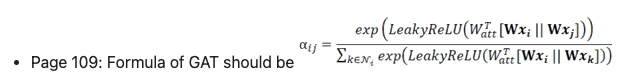

In [ ]:
### from test book
### however, it does not work since textbook focus on node classification where as our problem is more like edge-prediction

# def accuracy(y_pred, y_true):
#     return torch.sum(y_pred == y_true) / len(y_true)

# class GAT(nn.Module):
#     def __init__(self, in_dim, hidden_dim=32, heads=4):
#         super().__init__()
#         # GAT‑v2 layers
#         self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, concat=True)
#         self.gat2 = GATv2Conv(hidden_dim*heads, in_dim, heads=1,   concat=False)

#     def forward(self, x, edge_index):
#         h = F.dropout(x, p=0.6, training=self.training)
#         6. 7. Implementing a GAT in PyTorch Geometric 115
#         h = self.gat1(h, edge_index)
#         h = F.elu(h)
#         h = F.dropout(h, p=0.6, training=self.training)
#         h = self.gat2(h, edge_index)
#         return F.log_softmax(h, dim=1)

#     def fit(self, data, epochs):
#         criterion = torch.nn.CrossEntropyLoss()
#         optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)
#         self.train()
#         for epoch in range(epochs+1):
#             optimizer.zero_grad()
#             out = self(data.x, data.edge_index)
#             loss = criterion(out[data.train_mask], data.y[data.train_mask])
#             acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
#             loss.backward()
#             optimizer.step()
#             if(epoch % 20 == 0):
#                 val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
#                 val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
#                 print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')


#     @torch.no_grad()
#     def test(self, data):
#         self.eval()
#         out = self(data.x, data.edge_index)
#         acc = accuracy(out.argmax(dim=1)[data.test_mask],
#         data.y[data.test_mask])
#         return acc

Summary:
- Run two GATv2Conv layers (with an ELU after the first) to get learned node embeddings.
- For each edge, take its two endpoint embeddings, concatenate them, run through a little 2‑layer MLP (lin1→ReLU→lin2), and that final linear output is predicted rating.

In [ ]:

class GATv2Rec(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, heads=4):
        super().__init__()
        # GAT‑v2 layers --> same with textbook
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATv2Conv(hidden_dim*heads, in_dim, heads=1,   concat=False)
        # regression head
        self.lin1 = nn.Linear(in_dim*2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # two GAT‑v2 message‑passing layers
        x = F.elu(self.gat1(x, edge_index))
        x = self.gat2(x, edge_index)

        # edge‑level prediction head
        src, dst = edge_index
        e = torch.cat([x[src], x[dst]], dim=1)   # [num_edges, 2*in_dim]
        h = F.relu(self.lin1(e))
        return self.lin2(h).squeeze()

#### 7. Training models

In [ ]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = GATv2Rec(in_dim=data.x.size(1)).to(device)
opt       = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn   = nn.MSELoss()

data = data.to(device)
train_rmses, val_rmses = [], []
epochs = 500
threshold = 0.001

# track the last val RMSE at a 10‑epoch boundary
last_printed_val = float('inf')

for epoch in range(1, epochs+1):
    # —— training step ——
    model.train()
    opt.zero_grad()
    out = model(data)
    loss = loss_fn(out[data.train_mask], data.edge_label[data.train_mask])
    loss.backward()
    opt.step()
    train_rmses.append(math.sqrt(loss.item()))

    # —— validation step ——
    model.eval()
    with torch.no_grad():
        v_loss = loss_fn(out[data.val_mask], data.edge_label[data.val_mask])
        val_rmses.append(math.sqrt(v_loss.item()))

    # —— every 10 epochs: print & check stagnation ——
    if epoch % 10 == 0:
        curr_val = val_rmses[-1]
        curr_train = train_rmses[-1]
        print(f"Epoch {epoch:03d} | Train RMSE: {curr_train:.4f} | Val RMSE: {curr_val:.4f}")

        # if the change in val‐RMSE is smaller than threshold, stop
        if abs(last_printed_val - curr_val) < threshold:
            print(f"Stopping early at epoch {epoch} (ΔVal RMSE < {threshold})")
            break
        last_printed_val = curr_val

# —— final test RMSE ——
model.eval()
with torch.no_grad():
    t_loss = loss_fn(model(data)[data.test_mask], data.edge_label[data.test_mask])
    print(f"Test RMSE: {math.sqrt(t_loss.item()):.4f}")

# —— plot curves ——
plt.figure(figsize=(6,4))
plt.plot(train_rmses, label='Train RMSE')
plt.plot(val_rmses,   label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.legend()
plt.show()